# Project Goals: Data Cleaning, Explatory Data Analysis, and Building a high accuracy predictive regression model.

In [17]:
import numpy as np
import pandas as pd  
import seaborn as sn
import matplotlib.pyplot as plt
%matplotlib 
#Ml Libraries and models
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [19]:
data = pd.read_csv(r'Downloads\sa_healthcare_big_messy.csv')

#data.shape[0]
#data.shape[1]
#data["bmi"].isna().sum()
print(data)

      age     sex     bmi  children smoker         region     charges
0      55    male  29.900         0     no   Western Cape  R10,214.64
1      37  female  47.600         2    yes   Western Cape  R46,113.51
2      58    male  25.175         0     no   Eastern Cape  R11,931.13
3      39  female  23.870         5     no  KwaZulu-Natal   R8,582.30
4      18  female  31.350         4     no   Eastern Cape   R4,561.19
...   ...     ...     ...       ...    ...            ...         ...
5025  140  female  30.210         3     no        Gauteng   R7,537.16
5026   19    male  20.615         2     no        Gauteng   R2,803.70
5027   32  female  20.520         0     no   Eastern Cape   R4,544.23
5028   62  female  39.200         0     no   Western Cape  R13,470.86
5029   45    male  20.350         3     no  KwaZulu-Natal   R8,605.36

[5030 rows x 7 columns]


# Part A: Data Enginneering and Cleaning

In [21]:
# first thing we remove identical rows
data = data.drop_duplicates()

#Replace '' with NaN and 'R' with '' 
data['charges'] = data['charges'].str.replace('R','').str.replace(',','').astype(float)
data.head()

                                                                       

,age,sex,bmi,children,smoker,region,charges
0,55,male,29.900,0,no,Western Cape,10214.64
1,37,female,47.600,2,yes,Western Cape,46113.51
2,58,male,25.175,0,no,Eastern Cape,11931.13
3,39,female,23.870,5,no,KwaZulu-Natal,8582.30
4,18,female,31.350,4,no,Eastern Cape,4561.19


In [23]:
#Convert annual spent to numeric to solve the long comma numbers
data['charges'] = pd.to_numeric(data['charges'], errors ='coerce')
data.tail()

,age,sex,bmi,children,smoker,region,charges
4981,37,female,27.740,3,no,gauteng,7281.51
4984,51,male,31.635,0,no,GAUTENG,9174.14
4986,47,male,NaN,4,no,Eastern Cape,10407.09
4998,19,female,35.150,0,no,Gauteng,2134.90
4999,20,female,33.300,0,no,Western Cape,1880.49


# Inconsistencies Categorisation

In [25]:
#Update the region mappings to handle the variations
region_mapp = {
    'KZN':'Kwazulu-Natal',
    'W. Cape':'Western Cape' 
}
data['region'] = data['region'].map(region_mapp).fillna(data['region'])
print(data['region'])

0        Western Cape
1        Western Cape
2        Eastern Cape
3       KwaZulu-Natal
4        Eastern Cape
            ...      
4981          gauteng
4984          GAUTENG
4986     Eastern Cape
4998          Gauteng
4999     Western Cape
Name: region, Length: 1746, dtype: str


In [26]:
# Consistently capitalize all regions 
data['region'] = data['region'].str.title()
print(data['region'].head(20))


0      Western Cape
1      Western Cape
2      Eastern Cape
3     Kwazulu-Natal
4      Eastern Cape
5      Eastern Cape
6      Eastern Cape
7      Western Cape
8      Eastern Cape
9      Eastern Cape
10     Western Cape
11     Eastern Cape
12    Kwazulu-Natal
13     Eastern Cape
14     Western Cape
15          Gauteng
16     Eastern Cape
17          Gauteng
18     Western Cape
19     Eastern Cape
Name: region, dtype: str


# Bilogical Ouliers (age)

In [28]:
# The interval is 0 <= age <= 120  
data['age']=data['age'].clip(lower=0, upper = 120)
print(data['age'])

0       55
1       37
2       58
3       39
4       18
        ..
4981    37
4984    51
4986    47
4998    19
4999    20
Name: age, Length: 1746, dtype: int64


# Missingness

In [30]:
# Smart Imputation using Median
data['bmi'] = data.groupby('sex')['bmi'].transform(lambda x: x.fillna(x.median()) )
#print(data['bmi'])
# The Median is more robust than the mean because it is less sensitive to outliers  skewed distribution


In [31]:
# Clean the smoker column
data['smoker']=data['smoker'].replace('Unknown', np.nan)
print(data['smoker'])

0        no
1       yes
2        no
3        no
4        no
       ... 
4981     no
4984     no
4986     no
4998     no
4999     no
Name: smoker, Length: 1746, dtype: str


In [32]:
# Clean the sex Column
data['sex']= data['sex'].str.strip().str.upper()
#Replace variations with standard labels
data['sex'] = data['sex'].replace({
    "M":"MALE","F":"Female",
    "U": np.nan})
print(data['sex'].head(50))

0       MALE
1     FEMALE
2       MALE
3     FEMALE
4     FEMALE
5       MALE
6       MALE
7     FEMALE
8       MALE
9     FEMALE
10    FEMALE
11    FEMALE
12    FEMALE
13    FEMALE
14    FEMALE
15    FEMALE
16      MALE
17    FEMALE
18      MALE
19      MALE
20      MALE
21      MALE
22    FEMALE
23    FEMALE
24    FEMALE
25    FEMALE
26      MALE
27      MALE
28    FEMALE
29      MALE
30      MALE
31      MALE
32    FEMALE
33      MALE
34    FEMALE
35      MALE
36      MALE
37      MALE
38      MALE
39      MALE
40    FEMALE
41    FEMALE
42      MALE
43    FEMALE
44      MALE
45    FEMALE
46    FEMALE
47      MALE
48    FEMALE
49      MALE
Name: sex, dtype: str


# Categorical Encoding preparation for the regressssion

In [34]:
# Identify the colums
categor_cols=['sex','smoker','region']

#Apply one hot encoding
data_encoded = pd.get_dummies(data, columns=categor_cols, drop_first = True)
print(data_encoded.head())

   age     bmi  children   charges  sex_MALE  smoker_yes  region_Gauteng  \
0   55  29.900         0  10214.64      True       False           False   
1   37  47.600         2  46113.51     False        True           False   
2   58  25.175         0  11931.13      True       False           False   
3   39  23.870         5   8582.30     False       False           False   
4   18  31.350         4   4561.19     False       False           False   

   region_Kwazulu-Natal  region_Western Cape  
0                 False                 True  
1                 False                 True  
2                 False                False  
3                  True                False  
4                 False                False  


# Part B: Explarotory Data Analysis

In [36]:
print(data)

      age     sex     bmi  children smoker         region   charges
0      55    MALE  29.900         0     no   Western Cape  10214.64
1      37  FEMALE  47.600         2    yes   Western Cape  46113.51
2      58    MALE  25.175         0     no   Eastern Cape  11931.13
3      39  FEMALE  23.870         5     no  Kwazulu-Natal   8582.30
4      18  FEMALE  31.350         4     no   Eastern Cape   4561.19
...   ...     ...     ...       ...    ...            ...       ...
4981   37  FEMALE  27.740         3     no        Gauteng   7281.51
4984   51    MALE  31.635         0     no        Gauteng   9174.14
4986   47    MALE  30.400         4     no   Eastern Cape  10407.09
4998   19  FEMALE  35.150         0     no        Gauteng   2134.90
4999   20  FEMALE  33.300         0     no   Western Cape   1880.49

[1746 rows x 7 columns]


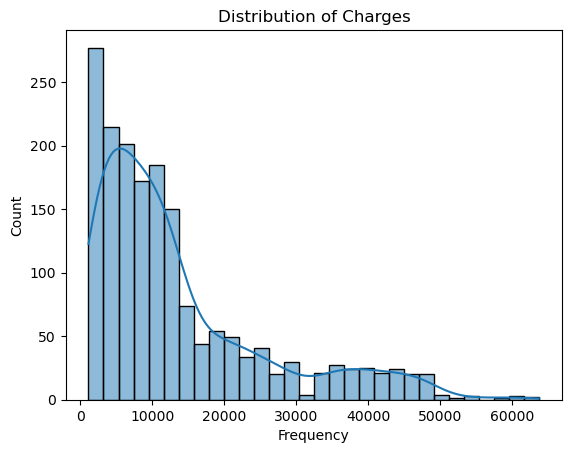

In [37]:
#Distribution plot
sn.histplot(data['charges'], kde = True)
plt.title('Distribution of Charges')
plt.xlabel('charges')
plt.xlabel('Frequency')
plt.show()

##### The distribution has a clear skew direction so we can say it is right(positive) skewed.

      age     sex     bmi  children smoker         region   charges
0      55    MALE  29.900         0     no   Western Cape  10214.64
1      37  FEMALE  47.600         2    yes   Western Cape  46113.51
2      58    MALE  25.175         0     no   Eastern Cape  11931.13
3      39  FEMALE  23.870         5     no  Kwazulu-Natal   8582.30
4      18  FEMALE  31.350         4     no   Eastern Cape   4561.19
...   ...     ...     ...       ...    ...            ...       ...
4981   37  FEMALE  27.740         3     no        Gauteng   7281.51
4984   51    MALE  31.635         0     no        Gauteng   9174.14
4986   47    MALE  30.400         4     no   Eastern Cape  10407.09
4998   19  FEMALE  35.150         0     no        Gauteng   2134.90
4999   20  FEMALE  33.300         0     no   Western Cape   1880.49

[1746 rows x 7 columns]


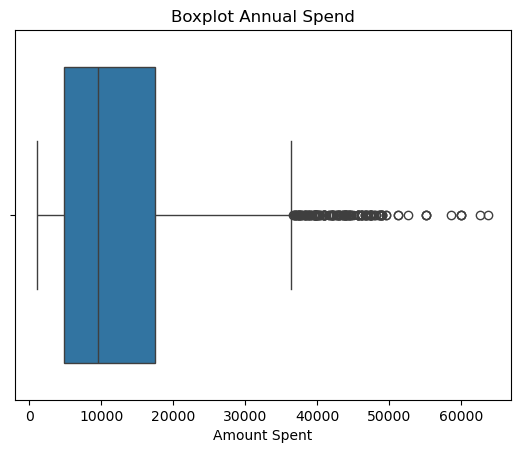

In [39]:
# Provincial Comparison (Box plott)
sn.boxplot(data['charges'], orient='h') # Horizontal boxplot
plt.title('Boxplot Annual Spend')
plt.xlabel('Amount Spent')
plt.show
print(data)

#####  The Expenditure symmetrically distributed with a median of about 40000 and the majority of values lying between 20000 and 60000, showing that most customer's expenditures are concentrated within this interval. 

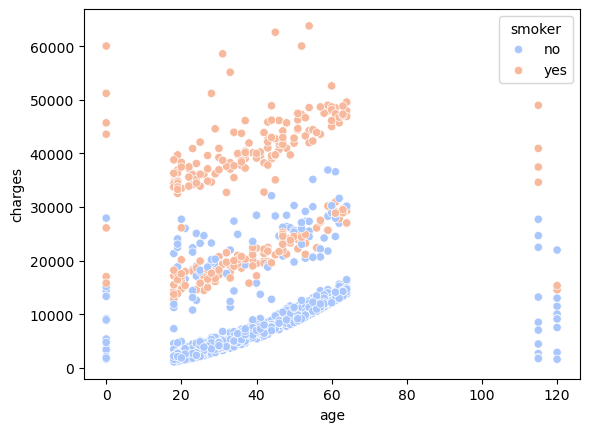

In [41]:
# Interaction Analysis Scatter plot of age versus Expenditures
sn.scatterplot(data=data,x='age',y='charges', hue = 'smoker', palette='coolwarm')
plt.xlabel("age")
plt.ylabel("charges")
plt.show()

##### The Scatter plot is distributed amongs all ages but more from the age of 20 to approximately 70 years. 

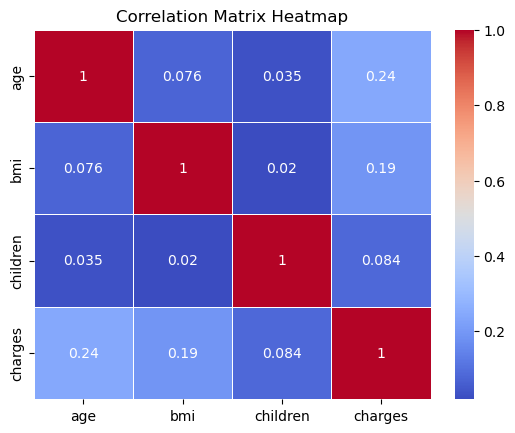

In [43]:
#Correlation Matrix Heatmap
corr_matrix =data.corr(numeric_only = True)  
#print(corr_matrix['charges'].sort_values(ascending = False))

#To Visualise this correlation(Heat)
sn.heatmap(corr_matrix, annot = True, cmap='coolwarm', linewidth=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

##### The variables on the matrix are closer to zero meaning they are largely independent to each other

# Part C: Machine Learning Modeling

In [46]:
print(data)

      age     sex     bmi  children smoker         region   charges
0      55    MALE  29.900         0     no   Western Cape  10214.64
1      37  FEMALE  47.600         2    yes   Western Cape  46113.51
2      58    MALE  25.175         0     no   Eastern Cape  11931.13
3      39  FEMALE  23.870         5     no  Kwazulu-Natal   8582.30
4      18  FEMALE  31.350         4     no   Eastern Cape   4561.19
...   ...     ...     ...       ...    ...            ...       ...
4981   37  FEMALE  27.740         3     no        Gauteng   7281.51
4984   51    MALE  31.635         0     no        Gauteng   9174.14
4986   47    MALE  30.400         4     no   Eastern Cape  10407.09
4998   19  FEMALE  35.150         0     no        Gauteng   2134.90
4999   20  FEMALE  33.300         0     no   Western Cape   1880.49

[1746 rows x 7 columns]


In [47]:
# Prepare the data for the two algorithms
X = data.drop('charges',axis=1) #feature(X) which is removed to be predicted
y = data['charges'] # label(y)

X = pd.get_dummies(X, columns=['sex','smoker','region'], drop_first=True) # Perform Encoding

# Split data into train/test(80/20) split
#from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=20, random_state=42)

#fit & evaluate linearRegression and forestregressor into the data
#from sklearn.linear_model import LinearRegression #1st model
lr = LinearRegression()
lr.fit(X_train,y_train)
lr_score = lr.score(X_test,y_test) #R^2

#fit randomforestregressor on the same data
#from sklearn.ensemble import RandomForestRegressor #2nd model
rf = RandomForestRegressor(n_estimators = 100)
rf.fit(X_train,y_train)
rf_score = lr.score(X_test,y_test) #R^2

#compare R^2 Goal = 0
print(f'Linear Regression R^2:{lr_score:.4f}')
print(f'Random Forest Regressor R^2:{rf_score:.4f}')



Linear Regression R^2:0.6343
Random Forest Regressor R^2:0.6343


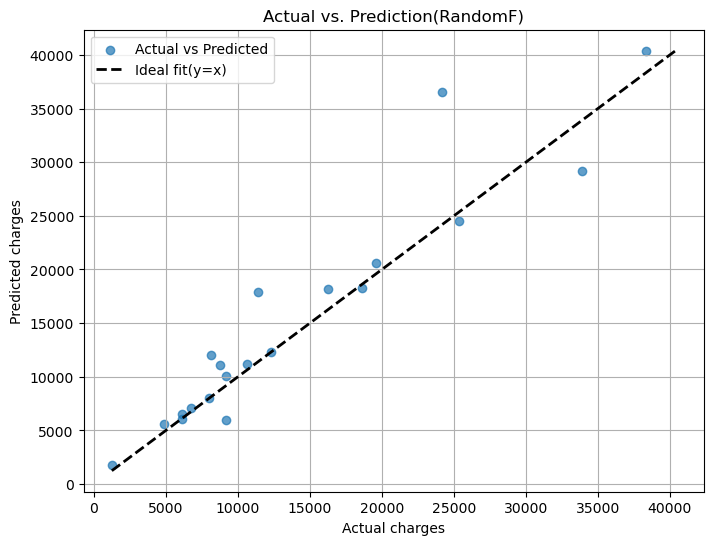

In [48]:
#Visual Validation
y_true = y_test
y_pred = rf.predict(X_test)# predicted values

#Scatterplot of actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha = 0.7, label="Actual vs Predicted")
#dashed line for perfect prediction
lims = [min(y_true.min(), y_pred.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', lw=2, label ='Ideal fit(y=x)')

plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title('Actual vs. Prediction(RandomF)')
plt.legend()
plt.grid(True)
plt.show()

##### The plot shows that the model is good at predicting charges. It shows a strong linear relationship between the two variables. 